# CBIS-DDSM dataset characterization

###### In this notebook, we compare the training and testing subsets of the CBIS-DDSM dataset. The objective is to understand the composition of the dataset and explore the distribution of key clinical variables.

### Loading the metadata files

#### Importing libraries

###### The following libraries are used to load and visualize the clinical metadata and mammographic images contained  in the CBIS-DDSM dataset.

In [1]:
import pandas as pd                    # Data manipulation and analysis
import matplotlib.pyplot as plt        # Image visualization

#### Training and testing subsets

In [2]:
# Load the CSV file containing the clinical and imaging information for calcification cases in the training and testing subset.

train = pd.read_csv(r"Downloads\calc_case_description_train_set.csv")
test = pd.read_csv(r"Downloads\calc_case_description_test_set.csv")

In [3]:
# Compare the number of lesions contained in the training and testing subsets of the calcification dataset

print("Train:", len(train))    # Count the number of lesions contained in the training subset
print("Test:", len(test))      # Count the number of lesions contained in the testing subset

Train: 1546
Test: 326


###### The calcification dataset contains 1,546 lesions in the training subset and 326 lesions in the testing subset. After exploring an individual case and its associated imaging data, this comparison provides a broader perspective  on the dataset organization. 

###### The results show that most lesions are included in the training subset, while a smaller portion is contained in the testing subset.

### Pathology distribution

###### Pathology indicates the diagnostic outcome associated with each abnormality. Examining its distribution helps identify  the proportion of benign and malignant findings present in the dataset.

In [4]:
# Count the number of lesions belonging to each pathology category in the training and testing subsets

train_pathology = train["pathology"].value_counts()
test_pathology = test["pathology"].value_counts()

print("Training Set")
print(train_pathology)

print("\nTesting Set")
print(test_pathology)

Training Set
pathology
MALIGNANT                  544
BENIGN                     528
BENIGN_WITHOUT_CALLBACK    474
Name: count, dtype: int64

Testing Set
pathology
BENIGN                     130
MALIGNANT                  129
BENIGN_WITHOUT_CALLBACK     67
Name: count, dtype: int64


In [5]:
# Create a table to compare the pathology distribution between the training and testing subsets
comparison = pd.DataFrame({
    "Train": train["pathology"].value_counts(),
    "Test": test["pathology"].value_counts()
})

comparison

,Train,Test
pathology,,
BENIGN,528,130
BENIGN_WITHOUT_CALLBACK,474,67
MALIGNANT,544,129


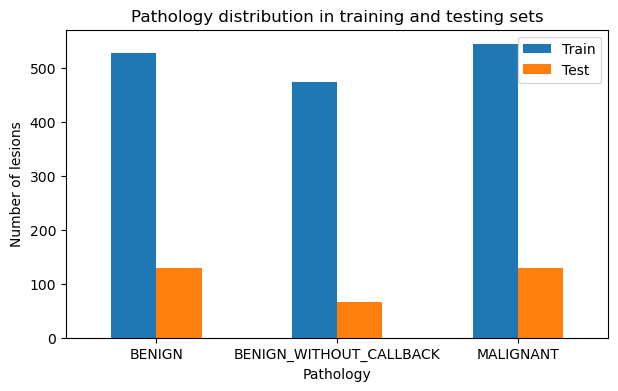

In [6]:
comparison.plot(kind="bar", figsize=(7,4))

plt.title("Pathology distribution in training and testing sets")
plt.xlabel("Pathology")
plt.ylabel("Number of lesions")
plt.xticks(rotation=0)
plt.show()

###### The pathology distribution shows that both subsets contain lesions from the three available diagnostic categories:  MALIGNANT, BENIGN, and BENIGN_WITHOUT_CALLBACK.

###### In the training subset, the number of malignant and benign lesions is relatively balanced, while the BENIGN_WITHOUT_CALLBACK category appears slightly less frequently. A similar pattern is observed in the testing subset, although with a smaller number of total cases.

###### These results indicate that both subsets include a representative sample of the pathology categories available in the dataset, allowing users to explore a wide range of clinical outcomes.

#### BI-RADS Assessment Distribution

###### The BI-RADS assessment category reflects the level of radiological suspicion associated with a lesion. Exploring its distribution helps characterize the diagnostic complexity of the dataset.

In [7]:
# Count the number of occurrences of each BI-RADS assessment category and sort the categories in ascending numerical order. 
train["assessment"].value_counts().sort_index() 

assessment
0     63
2    482
3     89
4    753
5    159
Name: count, dtype: int64

In [8]:
# Count the number of occurrences of each BI-RADS assessment category and sort the categories in ascending numerical order. 
test["assessment"].value_counts().sort_index()

assessment
0     13
2     71
3     24
4    178
5     40
Name: count, dtype: int64

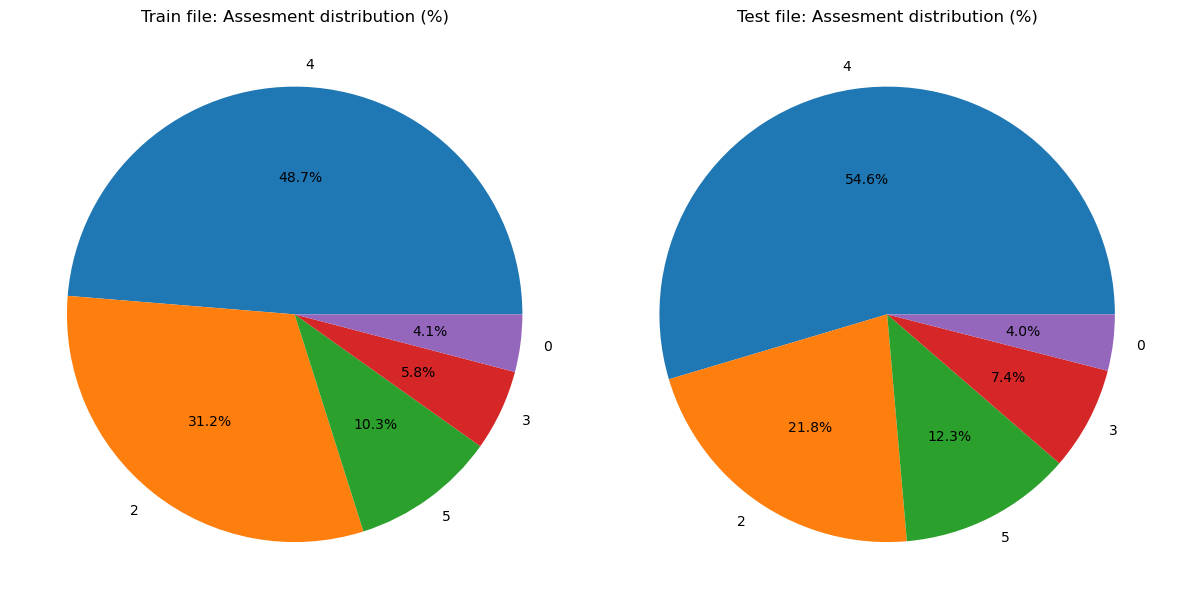

In [9]:
# Create a figure with one row and two columns to compare the BI-RADS assessment distribution in both subsets.
fig, axes = plt.subplots(1, 2, figsize=(12, 6)) # Create a figure with 1 row and 2 columns

# Generate a pie chart showing the percentage of lesions in each BI-RADS assessment category for the training set.
train["assessment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=axes[0]
)

axes[0].set_title("Train file: Assesment distribution (%)")
axes[0].set_ylabel("")

# Generate a pie chart showing the percentage of lesions in each BI-RADS assessment category for the testing set.
test["assessment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=axes[1]
)

axes[1].set_title("Test file: Assesment distribution (%)")
axes[1].set_ylabel("")

plt.tight_layout() # Adjust spacing between images
plt.show()          # Display the figure

###### The BI-RADS assessment distribution is similar in both subsets, with category 4 representing the largest proportion of cases. Categories 2 and 5 are also well represented, while categories 0 and 3 account for a smaller fraction of the dataset.

###### The similarity between the training and testing distributions suggests that both subsets contain comparable levels of radiological suspicion, providing a balanced partition of the data.

### Breast density distribution

###### Breast density is an important characteristic in mammography because it influences image appearance and lesion visibility.

In [10]:
# Count the number of lesions associated with each breast density category in the training set.

train["breast density"].value_counts().sort_index()

breast density
1    175
2    501
3    539
4    331
Name: count, dtype: int64

In [11]:
test["breast density"].value_counts().sort_index()

breast density
0      2
1     24
2    115
3    115
4     70
Name: count, dtype: int64

### Interactive exploration of breast density

###### The previous sections provided a general overview of the dataset composition. However, researchers often need to identify specific subsets of cases based on clinical characteristics.

###### The following example demonstrates how metadata can be filtered using breast density categories. Once a subset of cases has been selected, additional filters (such as pathology, BI-RADS assessment, calcification type, or calcification distribution) can be applied to further refine the search and identify cases of particular interest.

###### This approach illustrates how the dataset can be explored systematically to locate specific lesion profiles and better understand the relationships between different clinical variables.

In [12]:
density = int(input("Enter a breast density category (1-4): "))

selected_cases = train[train["breast density"] == density]

display(
    selected_cases[
        [
            "breast density",
            "calc type",
            "calc distribution",
            "assessment",
            "pathology"
        ]
    ]
)

Enter a breast density category (1-4):  2


,breast density,calc type,calc distribution,assessment,pathology
24,2,PLEOMORPHIC,CLUSTERED,4,MALIGNANT
25,2,PLEOMORPHIC,CLUSTERED,4,MALIGNANT
33,2,PLEOMORPHIC,CLUSTERED,4,MALIGNANT
34,2,PLEOMORPHIC,CLUSTERED,4,MALIGNANT
42,2,COARSE,NaN,2,BENIGN_WITHOUT_CALLBACK
...,...,...,...,...,...
1535,2,AMORPHOUS,SEGMENTAL,0,MALIGNANT
1540,2,AMORPHOUS-PLEOMORPHIC,SEGMENTAL,5,MALIGNANT
1541,2,AMORPHOUS-PLEOMORPHIC,SEGMENTAL,5,MALIGNANT
1542,2,AMORPHOUS,CLUSTERED,0,MALIGNANT


###### After selecting a breast density category, we can further restrict the search by pathology. This additional filtering step allows us to focus on lesions with specific diagnostic outcomes, such as malignant findings, and demonstrates how multiple metadata variables can be combined to identify highly specific subsets of cases.

In [13]:
# Enter a pathology category

pathology = input(
    "Enter a pathology category (MALIGNANT, BENIGN, BENIGN_WITHOUT_CALLBACK): "
)

filtered_cases = selected_cases[
    selected_cases["pathology"] == pathology
]

display(
    filtered_cases[
        [
            "breast density",
            "calc type",
            "calc distribution",
            "assessment",
            "pathology"
        ]
    ]
)

Enter a pathology category (MALIGNANT, BENIGN, BENIGN_WITHOUT_CALLBACK):  BENING


,breast density,calc type,calc distribution,assessment,pathology
